[VideoMAEv2](https://github.com/OpenGVLab/VideoMAEv2/tree/master)

[dataset](https://github.com/OpenGVLab/VideoMAEv2/blob/master/dataset/datasets.py)

In [1]:
%matplotlib inline

import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE" # tells OpenMP to not complain if it notices that two copies of OpenMP are loaded.

from IPython.display import Video
from IPython.display import Audio as play_audio
from torchvision.utils import make_grid
from torchcodec.encoders import VideoEncoder

def play_video(encoded_bytes):
    return Video(data=encoded_bytes.numpy().tobytes(),
                embed=True, width=640, height=360, mimetype="video/mp4")

import matplotlib.pyplot as plt

import sys
sys.path.append('../../../../')

In [2]:
from pathlib import Path
import math
import time
import random
import numbers
import datetime
from functools import partial

import cv2 
import torch
from torch.nn.modules.utils import _pair

from torchvision import transforms

import numpy as np
from PIL import Image

%load_ext autoreload
%autoreload 2

from computer_vision.video_mae.finetune_parameter_parser import parser
from computer_vision.video_mae.dataset.datasets import VideoClsDataset
from computer_vision.video_mae.dataset.video_transforms import _pil_interp

In [3]:
data_dirpath=Path('D:/data/UCF101')
root=data_dirpath/'UCF-101'
train_annotation_path=data_dirpath/'UCF101TrainTestSplits-RecognitionTask/trainlist01.txt'
val_annotation_path=data_dirpath/'UCF101TrainTestSplits-RecognitionTask/vallist01.txt'

mini_train=False
if not mini_train:
    pretrain_path=Path('D:/results/ucf101/video_mae/train/checkpoints/last.pth') 
    output_dirpath=Path('D:/results/ucf101/video_mae/finetune') 
    arguments= f"""--data_root {root} --train_data_path {train_annotation_path} --val_data_path {val_annotation_path} 
    --output_dir {output_dirpath} --finetune {pretrain_path} 
    --data_set UCF101 --nb_classes 101  --batch_size 3 --input_size 224
    --short_side_size 224 --num_frames 16 --sampling_rate 4 --num_sample 2 --num_workers 0 --opt adamw
    --lr 1e-3 --drop_path 0.3 --clip_grad 5.0 --layer_decay 0.9 --opt_betas 0.9 0.999 --weight_decay 0.1
    --test_num_segment 5 --test_num_crop 3 --dist_eval
    --warmup_epochs 5 --epochs 35  --print_freq 20 --device cpu --time 12 --resume
    """ # --use-cutmix-mixup
else:
    pretrain_path=Path('D:/results/ucf101/video_mae/mini_train/checkpoints/last.pth') 
    output_dirpath=Path('D:/results/ucf101/video_mae/mini_finetune') 
    arguments= f"""--data_root {root} --train_data_path {train_annotation_path} --val_data_path {val_annotation_path} 
    --output_dir {output_dirpath}  --finetune {pretrain_path} 
    --data_set UCF101 --nb_classes 101  --batch_size 3 --input_size 224
    --short_side_size 224 --num_frames 16 --sampling_rate 4 --num_sample 2 --num_workers 0 --opt adamw
    --lr 1e-3 --drop_path 0.3 --clip_grad 5.0 --layer_decay 0.9 --opt_betas 0.9 0.999 --weight_decay 0.1
    --test_num_segment 5 --test_num_crop 3 --dist_eval 
    --warmup_epochs 5 --print_freq 20 --epochs 35  --device cpu --resume
    --n_steps 12 --n_epochs 2 --time 0.5
    """ # --use-cutmix-mixup --time 18 --resume

known_args, _=parser.parse_known_args(args=arguments.split())
if known_args.enable_deepspeed:
    parser=deepspeed.add_config_arguments(parser)
    ds_init=deepspeed.initialize
else: ds_init=None
args=parser.parse_args(arguments.split())


In [4]:
# dataset_train=VideoClsDataset(data_root=args.data_root, anno_path=args.train_data_path, mode='train', clip_len=args.num_frames, 
#                         frame_sample_rate=args.sampling_rate, num_segment=1, test_num_segment=args.test_num_segment,
#                         test_num_crop=args.test_num_crop, num_crop=1, keep_aspect_ratio=True, crop_size=args.input_size,
#                         short_side_size=args.short_side_size, new_height=256, new_width=320, args=args)
args.nb_classes=101

# dataset_val=VideoClsDataset(data_root=args.data_root, anno_path=args.val_data_path, mode='validation', clip_len=args.num_frames, 
#                         frame_sample_rate=args.sampling_rate, num_segment=1, test_num_segment=args.test_num_segment,
#                         test_num_crop=args.test_num_crop, num_crop=1, keep_aspect_ratio=True, crop_size=args.input_size,
#                         short_side_size=args.short_side_size, new_height=256, new_width=320, args=args)

dataset_test=VideoClsDataset(data_root=args.data_root, anno_path=args.val_data_path, mode='test', clip_len=args.num_frames, 
                        frame_sample_rate=args.sampling_rate, num_segment=1, test_num_segment=args.test_num_segment,
                        test_num_crop=args.test_num_crop, num_crop=3, keep_aspect_ratio=True, crop_size=args.input_size,
                        short_side_size=args.short_side_size, new_height=256, new_width=320, args=args)

In [5]:
from computer_vision.video_mae.dataset.video_transforms import (Compose, Resize, CenterCrop, ClipToTensor, Normalize)
from computer_vision.video_mae.dataset.pretrained_datasets import IMAGENET_DEFAULT_MEAN, IMAGENET_DEFAULT_STD

In [6]:
index=90
# def __getitem__(self, index):
if dataset_test.mode=='train': frames_list, label_list, index_list, some_set=dataset_test._get_train_item(index=index, args=dataset_train.args, 
                                                                                                            scale_t=1)
elif dataset_test.mode=='validation': frames, label, fname=dataset_test._get_val_item(index=index)
elif dataset_test.mode=='test': frames, label, fname, chunk_nb, split_nb=dataset_test._get_test_item(index=index)
else: raise ValueError(f"mode {dataset_test.mode} is not supported, must be 'test', 'validation', 'train'")

type(frames)=<class 'torch.Tensor'>, frames.shape=torch.Size([3, 16, 224, 224]), frames.dtype=torch.float32, (-2.12, 2.64)
fname='v_Archery_g03_c01', chunk_nb=0, split_nb=0


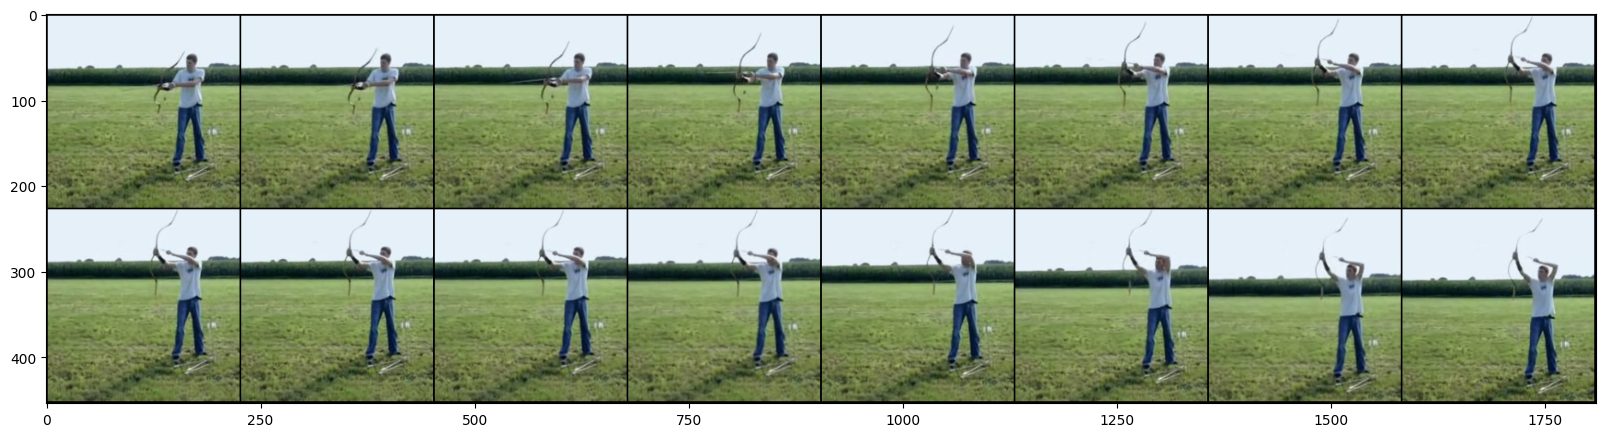

In [8]:
print(f"{type(frames)=}, {frames.shape=}, {frames.dtype=}, ({frames.min().item():.2f}, {frames.max().item():.2f})")
print(f"{fname=}, {chunk_nb=}, {split_nb=}")
plt.figure(figsize=(20,20))
plt.imshow(make_grid(frames.transpose(0,1), normalize=True).permute(1,2,0))

type(buffer)=<class 'numpy.ndarray'>, buffer.shape=(38, 240, 320, 3), buffer.dtype=dtype('uint8'), (0.00, 255.00)
type(buffer)=<class 'numpy.ndarray'>, buffer.shape=(38, 224, 298, 3), buffer.dtype=dtype('uint8'), (0.00, 255.00)


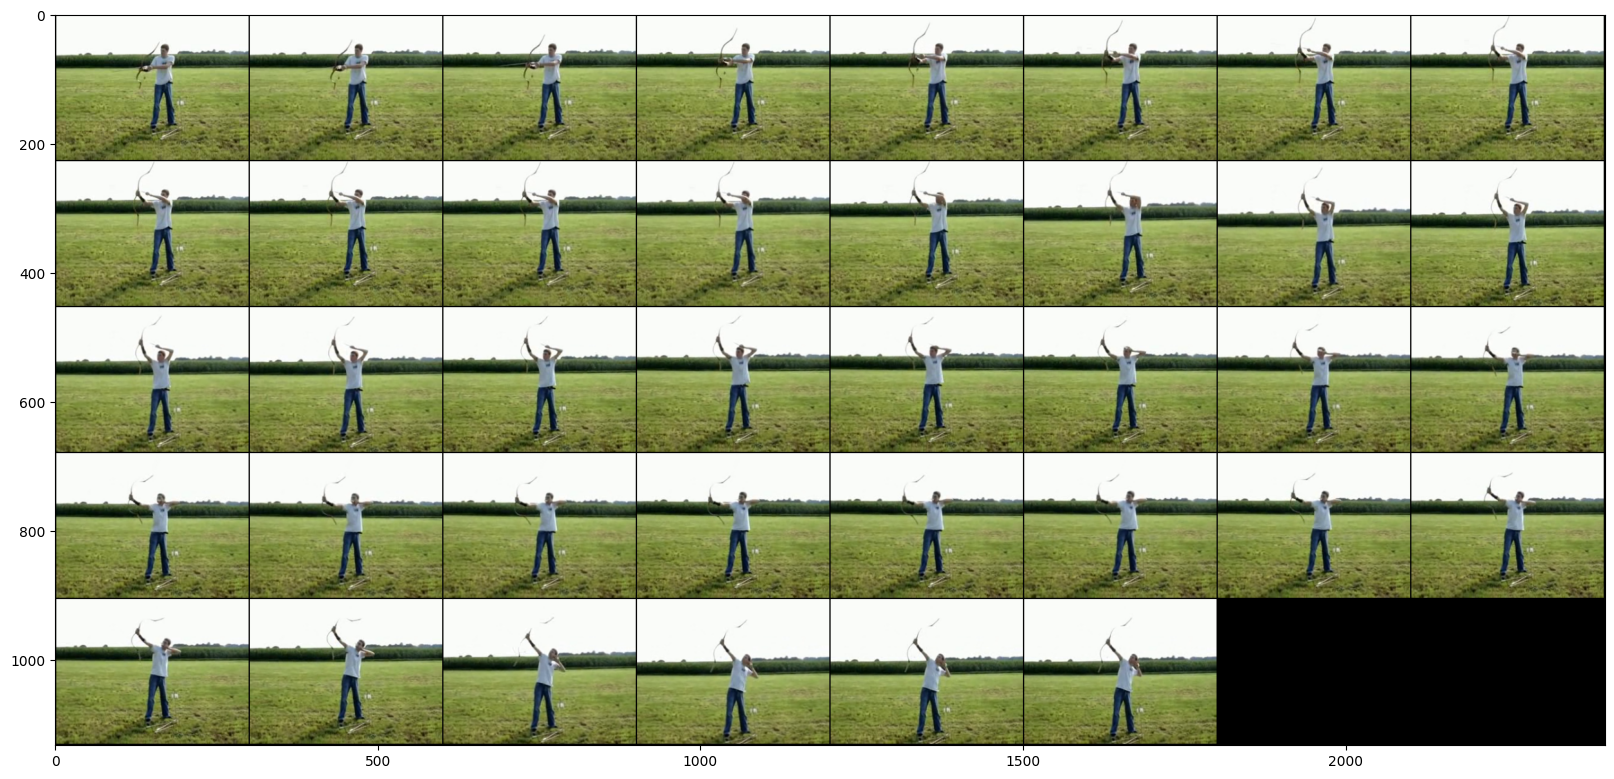

In [7]:
sample=dataset_test.test_dataset[index]
chunk_nb,split_nb=dataset_test.test_seg[index]
buffer=dataset_test.load_video(sample)

while len(buffer)==0:
    warnings.warn(f"video {dataset_test.test_dataset[index]}, temporal {chunk_nb}, spatial {split_nb} not found during testing")
    index=np.random.randint(dataset_test.__len__())
    sample=dataset_test.test_dataset[index]
    chunk_nb, split_nb=dataset_test.test_seg[index]
    buffer=dataset_test.load_video(sample)

print(f"{type(buffer)=}, {buffer.shape=}, {buffer.dtype=}, ({buffer.min().item():.2f}, {buffer.max().item():.2f})")
buffer=dataset_test.data_resize(buffer) # list of (H,W,C)
if isinstance(buffer, list): buffer=np.stack(buffer, 0) # (T,H,W,C)
print(f"{type(buffer)=}, {buffer.shape=}, {buffer.dtype=}, ({buffer.min().item():.2f}, {buffer.max().item():.2f})")

    
plt.figure(figsize=(20,20))
plt.imshow(make_grid(torch.from_numpy(buffer.transpose(0,3,1,2))).permute(1,2,0))

type(buffer)=<class 'numpy.ndarray'>, buffer.shape=(16, 224, 224, 3), buffer.dtype=dtype('uint8'), (0.00, 255.00)
type(buffer)=<class 'torch.Tensor'>, buffer.shape=torch.Size([3, 16, 224, 224]), buffer.dtype=torch.float32, (-2.12, 2.64)


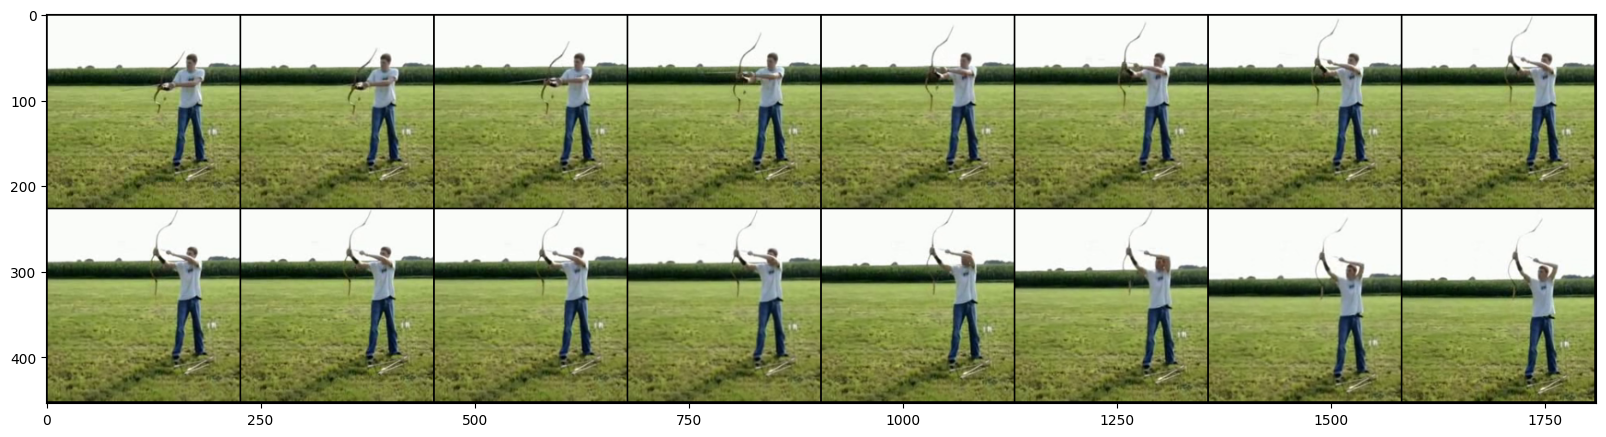

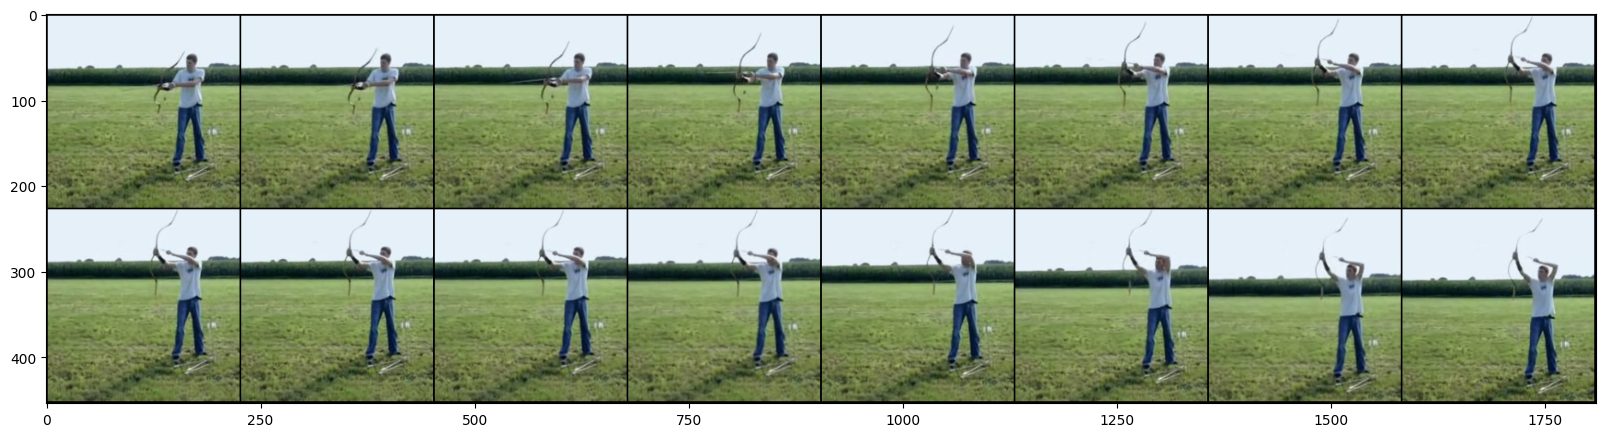

In [8]:
# Calculate a stride (step size) to evenly distribute a specific number of crops across the longer dimension
# self.short_side_size is the target crop size (e.g., 224 pixel)
# spatial_step: distance between the starting coordinates of each consecutive crop
# example: A video of 324 pixels wide and target crop of 224 pixels, using 3 crop
# - excess space: 324-224=100 pixels
# - intervals: 3-1=2
# - spatial_step= 100/2=50
# crops would start at horizontal offsets of 0 (left), 50 (center), 100 (right-- 100+224=324 which is the edge)
spatial_step=1.*(max(buffer.shape[1:3])-dataset_test.short_side_size)/(dataset_test.test_num_crop-1)
spatial_start=int(split_nb*spatial_step) # split_nb: index of spatial crops
if dataset_test.sparse_sample: # sparse in time
    # chunk_nb ranging from [0, self.test_num_segment-1]
    # the following allow us to sample every self.test_num_segment frame
    # Example: a video with 16 frames, self.test_num_segment=4, we have
    # chunk_nb     slice syntax       frames selected
    # 0             0::4              0,4,8,12
    # 1             1::4              1,5,9,13
    # 2             2::4              2,6,10,14
    # 3             3::4              3,7,11,15
    temporal_start=chunk_nb # chunk_nb:index of temporal segment sampled , temporal_start: index to frame the video reader should start decoding from
    if buffer.shape[1]>=buffer.shape[2]: # if H>=W
        buffer=buffer[temporal_start::dataset_test.test_num_segment, # sample T from temporal_start with the step of dataset_test.test_num_segment
                      spatial_start:spatial_start+dataset_test.short_side_size] # sample along H dimension
    else:
        buffer=buffer[temporal_start::dataset_test.test_num_segment,:,
                      spatial_start:spatial_start+dataset_test.short_side_size]
else:
    temporal_step=max(1.*(buffer.shape[0]-dataset_test.clip_len)/(dataset_test.test_num_segment-1), 0)
    temporal_start=int(chunk_nb*temporal_step)
    if buffer.shape[1]>=buffer.shape[2]: # if H>=W
        buffer=buffer[temporal_start:temporal_start+dataset_test.clip_len, 
                      spatial_start:spatial_start+dataset_test.short_side_size]
    else:
        buffer=buffer[temporal_start:temporal_start+dataset_test.clip_len,:,
                      spatial_start:spatial_start+dataset_test.short_side_size]

print(f"{type(buffer)=}, {buffer.shape=}, {buffer.dtype=}, ({buffer.min().item():.2f}, {buffer.max().item():.2f})")
plt.figure(figsize=(20,20))
plt.imshow(make_grid(torch.from_numpy(buffer.transpose(0,3,1,2))).permute(1,2,0))

# After the above operation, buffer will be (T,H,W,C) np.ndarray where H and W will be at target desired size
buffer=dataset_test.data_transfrom(buffer) # (C,T,H,W) tensor
print(f"{type(buffer)=}, {buffer.shape=}, {buffer.dtype=}, ({buffer.min().item():.2f}, {buffer.max().item():.2f})")
plt.figure(figsize=(20,20))
plt.imshow(make_grid(buffer.transpose(0,1), normalize=True).permute(1,2,0))
    
